Anomalies Detected

     Order Date  Total amount  Anomaly
54   2011-03-18    28106.7160     True
197  2011-09-08    14228.4280     True
207  2011-09-19     9338.6370     True
211  2011-09-23    10662.3370     True
263  2011-11-17    11544.2740     True
501  2012-09-17    11525.0060     True
544  2012-11-08    12196.9970     True
618  2013-02-02     8996.7840     True
652  2013-03-14     8866.8820     True
683  2013-04-17     9335.0860     True
715  2013-05-24    10560.9780     True
833  2013-10-03    18452.9720     True
903  2013-12-18    12185.1340     True
910  2013-12-26    10488.0550     True
978  2014-03-24    14816.0680     True
1109 2014-08-18     9517.2880     True
1113 2014-08-22     8551.0540     True
1124 2014-09-03     9354.8540     True
1170 2014-10-23    15158.8770     True
1182 2014-11-05    10668.0960     True
1195 2014-11-18    13694.8828     True
1210 2014-12-03     9951.1820     True


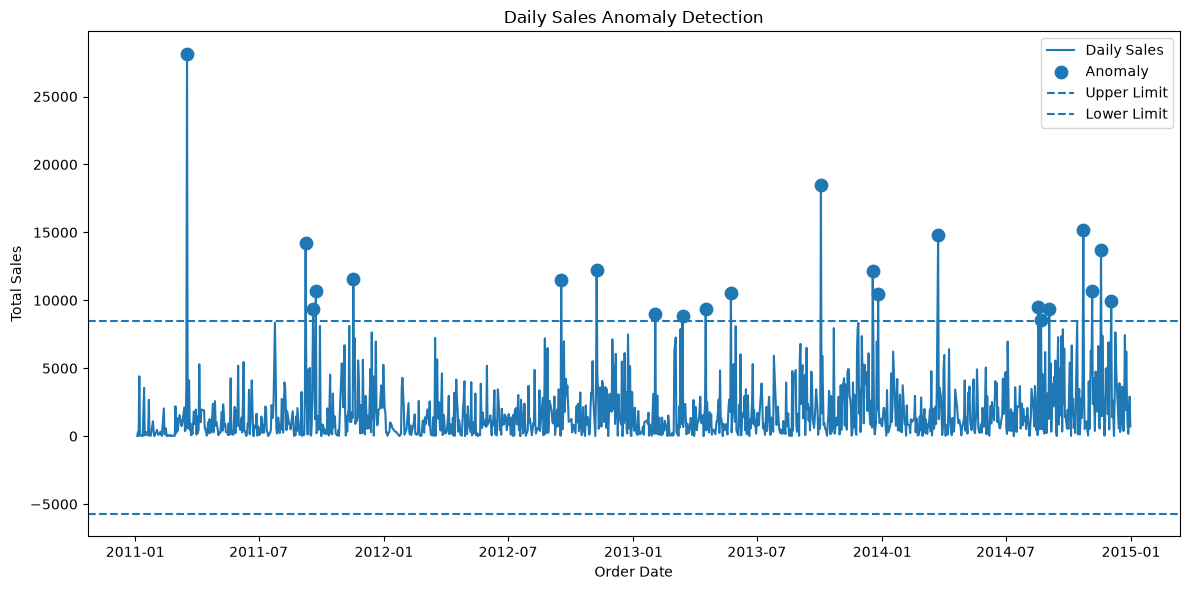


Anomaly detection completed successfully.
Total anomalies: 22


In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("../../week1/preprocessing/cleaned_dataset.csv")

# ------------------------------------------
# Check Required Columns
# ------------------------------------------

required_columns = ["Order Date", "Total amount"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"{col} column not found in dataset.")

# ------------------------------------------
# Convert Order Date
# ------------------------------------------

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

# ------------------------------------------
# Daily Sales
# ------------------------------------------

daily_sales = (
    df.groupby("Order Date")["Total amount"]
      .sum()
      .reset_index()
)

# ------------------------------------------
# Calculate Mean and Standard Deviation
# ------------------------------------------

mean_sales = daily_sales["Total amount"].mean()
std_sales = daily_sales["Total amount"].std()

# Calculate Quartiles
Q1 = daily_sales["Total amount"].quantile(0.25)
Q3 = daily_sales["Total amount"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 3.0 * IQR
upper_limit = Q3 + 3.0 * IQR

# Detect anomalies
daily_sales["Anomaly"] = (
    (daily_sales["Total amount"] < lower_limit) |
    (daily_sales["Total amount"] > upper_limit)
)

# ------------------------------------------
# Display Results
# ------------------------------------------

print("Anomalies Detected\n")

print(daily_sales[daily_sales["Anomaly"]])

# ------------------------------------------
# Visualization
# ------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    daily_sales["Order Date"],
    daily_sales["Total amount"],
    label="Daily Sales"
)

anomalies = daily_sales[daily_sales["Anomaly"]]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Total amount"],
    marker="o",
    s=80,
    label="Anomaly"
)

plt.axhline(
    upper_limit,
    linestyle="--",
    label="Upper Limit"
)

plt.axhline(
    lower_limit,
    linestyle="--",
    label="Lower Limit"
)

plt.title("Daily Sales Anomaly Detection")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------
# Save Output
# ------------------------------------------

daily_sales.to_csv(
    "anomaly_detection_results.csv",
    index=False
)

print("\nAnomaly detection completed successfully.")
print("Total anomalies:", daily_sales["Anomaly"].sum())